<a href="https://colab.research.google.com/github/GaL92/Curso.Prep.Henry/blob/master/GABI_PDI_TP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Procesamiento de Imágenes - Diplodatos 2024

Trabajo Práctico

Importante: Para obtener los créditos de materia completa, resolver al menos 1 ejercicio optativo de cada trabajo práctico.

In [ ]:
integrantes = ["integrante1", "integrante2", "integrante2"]
print(*integrantes, sep="\n")


Importar las librerías necesarias

In [1]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Abrir imágenes de demo incluídas en la biblioteca. Para evitar cargar desde disco, pueden utilizar estas imágenes para resolver el TP. Si utilizan otras adjuntarlas en la entrega para reproducibilidad.

<ipython-input-31-beaddcac30db>:23: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_2 = imageio.imread('imageio:coffee.png')


matriz transformada: [[0.08235294 0.05098039 0.03137255]
 [0.08235294 0.05098039 0.03529412]
 [0.07843137 0.04313725 0.03137255]
 ...
 [0.61960784 0.28627451 0.14901961]
 [0.56470588 0.25098039 0.11764706]
 [0.56078431 0.23529412 0.11372549]]


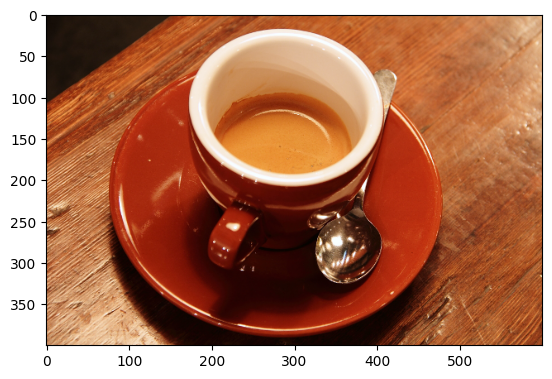

In [31]:
#img_1 = imageio.imread('imageio:wikkie.png')


# Otras imágenes (extraído de la documentación de imageio)

# bricks.jpg: A (repeatable) texture of stone bricks
# wood.jpg: A (repeatable) texture of wooden planks
# astronaut.png: Image of the astronaut Eileen Collins
# camera.png: A grayscale image of a photographer
# checkerboard.png: Black and white image of a chekerboard
# chelsea.png: Image of Stefan’s cat
# clock.png: Photo of a clock with motion blur (Stefan van der Walt)
# coffee.png: Image of a cup of coffee (Rachel Michetti)
# coins.png: Image showing greek coins from Pompeii
# horse.png: Image showing the silhouette of a horse (Andreas Preuss)
# hubble_deep_field.png: Photograph taken by Hubble telescope (NASA)
# immunohistochemistry.png: Immunohistochemical (IHC) staining
# moon.png: Image showing a portion of the surface of the moon
# page.png: A scanned page of text
# text.png: A photograph of handdrawn text
# wikkie.png: Image of Almar’s cat

img_2 = imageio.imread('imageio:coffee.png')

plt.imshow(img_2)
#print(img_2.shape)
#print(type(img_2))
#print('canales sin normalizar:',img_2)
img_2=img_2/255
#print('canales normalizados:',img_2)

#Transformar dimensiones de la matriz de la imagen para encontrar matriz YIQ

img_2_transf=img_2.reshape((400*600,3))

print('matriz transformada:',img_2_transf)


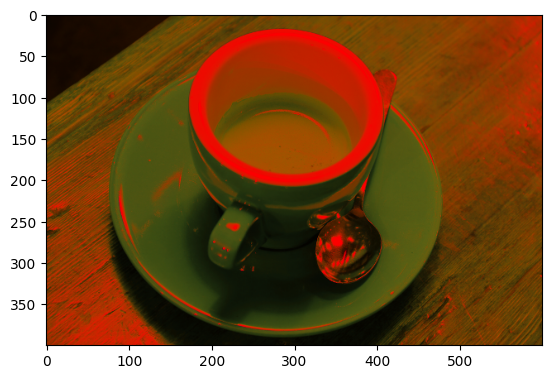

In [38]:
#Matriz M para pasar de RGB a YIQ
matriz_transformacion = np.array([
    [0.299, 0.587, 0.114],
    [0.595716, -0.274453, -0.321263],
    [0.211456, -0.522591, 0.311135]
])

def apply_matrix(img, M):
    return np.matmul( img, M.T ).reshape(img.shape)

img_YIQ = apply_matrix(img_2_transf,matriz_transformacion)

img_YIQ=img_YIQ.reshape(400,600,3)

plt.imshow(img_YIQ)

# Ejercicio 1.1
La propuesta para esta actividad consiste en manipular independientemente la luminancia y la saturación de una imagen.
Para ello convertimos cada pixel de la imagen del espacio RGB al espacio YIQ, luego alteramos los valores de Y (para cambiar la luminancia) o de IQ (para cambiar la saturación).
Con los nuevos valores de YIQ, convertimos a RGB nuevamente y obtenemos una nueva imagen.

# Ejercicio 1.2
Desarrollar un aplicativo o notebook que pueda abrir una imagen, manipule su histograma de luminancias, y luego ver la imagen procesada. Se debe poder elegir filtro raíz, cuadrado, o lineal a trozos.
Los controles para elegir los filtros los organizan como les resulte más cómodo.

# Ejercicio 2.1
Implementar un aplicativo o notebook que levante una imagen en nivel de gris (o que la convierta a YIQ y retenga solo el Y) y aplique el filtrado por convolución aquí visto:
1. Pasabajos: Plano, Bartlett 3x3, Gaussiano 5x5.
2. Detectores de bordes: Laplaciano v4, Sobel 4 orientaciones.
3. Pasabanda.

Respecto del “cierre” de la imagen cerca de los bordes, implementar la técnica no ma- temáticamente perfecta de “repetir” artificialmente filas o columnas cuando estas hagan falta. Por ejemplo, si el kernel es 3x3 y estoy en la primera columna, y no hay ninguna columna a la izquierda, entonces repito la primera columna como si estuviese en la imagen original.

#Ejercicio 2.2
Desarrollar un aplicativo o notebook que implemente los conceptos de morfología en niveles de gris aquí descriptos, con un elemento estructurante 3x3. El mismo incluirá las siguientes funciones:
- Erosión (tomar el mínimo valor de luminancia de la vecindad).
- Dilatación (máximo)
- Apertura, cierre, borde morfológico
- Mediana
- Top-hat
Incluir la capacidad de copiar la componente de la imagen procesada en la componente original, para poder aplicar dos o más filtrados en secuencia.

# Ejercicios Optativos. Ver presentación para más detalle
Recordá que hay ejercicios opcionales especificados en la presentación correspondiente al trabajo práctico.